### Hello Soft Clustering (GMM)

Recall from HW1 we did K-means clustering. Fitting a GMM on a set of points can be considered
as another method to do clustering but now with soft assignments. Consider the same set of
points we used in HW1.

In class, we showed that we could fit a GMM on 1-dimensional data by using Expectation
Maximization (EM). The algorithm for doing EM on N-dimensional GMM is very similar. The exact
algorithm is as follows:

Initialization: Initialize the mixture weights, $φ = mj$, where j is the mixture number,

means of each Gaussian μj

(now a vector of N dimensions), and covariance matrices of each

Gaussian, Σj
.
Expectation: Find the soft assignments for each data point wn,j where n corresponds to the
sample index.

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import copy
import os


<Axes: xlabel='x', ylabel='y'>

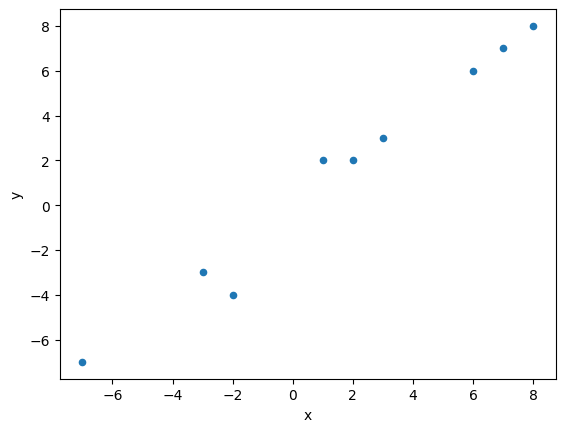

In [83]:
d={ 'x' : [1,3,2,8,6,7,-3,-2,-7],
    'y' : [2,3,2,8,6,7,-3,-4,-7],
    'group' : [None]*9 }


df = pd.DataFrame(d)

df.plot.scatter(x='x',y='y')

In [84]:
X = np.array([[1, 2], [3, 3], [2, 2], [8, 8], [6, 6], [7, 7], [-3, -3], [-2, -4], [-7, -7]])
n_samples, n_features = X.shape
k = 3

# Initialization
mu = np.array([[3.0, 3.0], [2.0, 2.0], [-3.0, -3.0]])
sigma = [np.eye(n_features) for _ in range(k)]
phi = np.array([1/3, 1/3, 1/3])

# Responsibilities (soft assignments) matrix
w = np.zeros((n_samples, k))

In [85]:
def multivariate_normal(x, mean, cov):
    """Calculate the probability density of x given mean and cov."""
    k = len(mean)
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    diff = x - mean
    exponent = -0.5 * (diff @ inv @ diff.T)
    return (1.0 / (np.sqrt((2 * np.pi)**k * det))) * np.exp(exponent)

# Define a small regularization constant
epsilon = 1e-6

for iteration in range(3):
    # --- E-STEP ---
    for i in range(n_samples):
        for j in range(k):
            # Calculate PDF
            prob = phi[j] * multivariate_normal(X[i], mu[j], sigma[j])
            w[i, j] = prob
        
        # Safety check: if a point is so far away that all probs are 0, 
        # add a tiny value to avoid division by zero
        sum_w = np.sum(w[i, :])
        if sum_w == 0:
            w[i, :] = 1.0 / k
        else:
            w[i, :] /= sum_w

    # --- M-STEP ---
    n_j = np.sum(w, axis=0) # Sum weights for each cluster
    
    for j in range(k):
        phi[j] = n_j[j] / n_samples
        mu[j] = (w[:, j] @ X) / n_j[j]
        
        diff = X - mu[j]
        # Calculate covariance AND add epsilon to the diagonal (Regularization)
        sigma[j] = (w[:, j] * diff.T @ diff) / n_j[j]
        sigma[j] += np.eye(n_features) * epsilon  
        
# Final hard assignment for visualization
labels = np.argmax(w, axis=1)

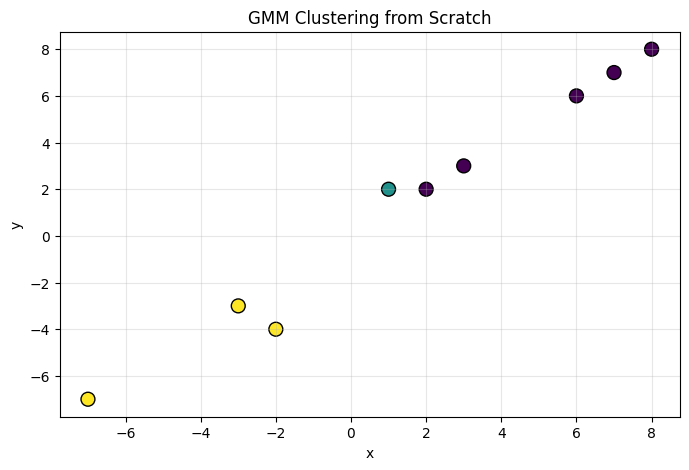

In [86]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=100, edgecolors='k')
plt.title("GMM Clustering from Scratch")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

#### 1. 
Using 3 mixtures, initialize your Gaussian with means (3,3), (2,2), and (-3,-3), 
and standard Covariance, I, the identity matrix. Use equal mixture weights as the initial weights.
Repeat three iterations of EM. Write down wn,j
, mj
, μ⃑j
, Σj and plot the likelihood distributions (3
Gaussians) of each feature for each EM iteration. (You may do the calculations by hand or write
code to do so) (5 points)

In [87]:
def mvn_pdf(x, mean, cov):
    n = len(mean)
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    diff = x - mean
    exponent = -0.5 * (diff @ inv @ diff.T)
    return (1.0 / np.sqrt(((2 * np.pi)**n) * det)) * np.exp(exponent)

for iter in range(1, 4):
    # --- E-STEP ---
    w = np.zeros((n_samples, k))
    for i in range(n_samples):
        for j in range(k):
            w[i, j] = phi[j] * mvn_pdf(X[i], mu[j], sigma[j])
        w[i, :] /= np.sum(w[i, :])

    # --- M-STEP ---
    n_j = np.sum(w, axis=0)
    for j in range(k):
        phi[j] = n_j[j] / n_samples
        mu[j] = (w[:, j] @ X) / n_j[j]
        diff = X - mu[j]
        sigma[j] = (w[:, j] * diff.T @ diff) / n_j[j] + np.eye(n_features) * 1e-6

    print(f"\n--- Iteration {iter} ---")
    print(f"Weights (phi): {phi}")
    print(f"Means (mu):\n{mu}")


--- Iteration 1 ---
Weights (phi): [0.66360661 0.11111112 0.22528227]
Means (mu):
[[ 3.84485206  3.84485206]
 [ 1.00000008  2.        ]
 [-4.42073716 -5.40715398]]

--- Iteration 2 ---
Weights (phi): [0.76712115 0.11111111 0.12176773]
Means (mu):
[[ 2.41470872  2.41470872]
 [ 1.          2.        ]
 [-2.43757993 -4.26254796]]

--- Iteration 3 ---
Weights (phi): [0.77544577 0.11111111 0.11344312]
Means (mu):
[[ 2.31363933  2.31363933]
 [ 1.          2.        ]
 [-2.10278312 -4.06166987]]


#### 2. Plot the log likelihood of the model given the data after each EM step. Does it goes up
every iteration just as we learned in class? (3 points)


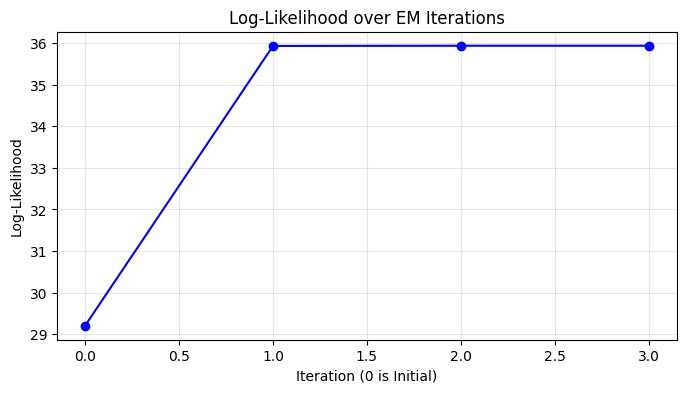

Log-Likelihoods: [np.float64(29.204849045685165), np.float64(35.928899068480135), np.float64(35.934046038726784), np.float64(35.934046038726784)]


In [88]:
epsilon = 1e-6

log_likelihoods = []

def mvn_pdf(x, mean, cov):
    n = len(mean)
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    diff = x - mean
    exponent = -0.5 * (diff @ inv @ diff.T)
    return (1.0 / np.sqrt(((2 * np.pi)**n) * det)) * np.exp(exponent)

# Calculate initial Log-Likelihood before any updates
initial_ll = sum(np.log(sum(phi[j] * mvn_pdf(x, mu[j], sigma[j]) for j in range(k))) for x in X)
log_likelihoods.append(initial_ll)

for iter in range(3):
    # --- E-STEP ---
    w = np.zeros((n_samples, k))
    for i in range(n_samples):
        for j in range(k):
            w[i, j] = phi[j] * mvn_pdf(X[i], mu[j], sigma[j])
        w[i, :] /= np.sum(w[i, :])

    # --- M-STEP ---
    n_j = np.sum(w, axis=0)
    for j in range(k):
        phi[j] = n_j[j] / n_samples
        mu[j] = (w[:, j] @ X) / n_j[j]
        diff = X - mu[j]
        sigma[j] = (w[:, j] * diff.T @ diff) / n_j[j] + np.eye(n_features) * epsilon
    
    # Calculate Log-Likelihood after update
    ll = sum(np.log(sum(phi[j] * mvn_pdf(x, mu[j], sigma[j]) for j in range(k))) for x in X)
    log_likelihoods.append(ll)

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(range(len(log_likelihoods)), log_likelihoods, marker='o', linestyle='-', color='b')
plt.title("Log-Likelihood over EM Iterations")
plt.xlabel("Iteration (0 is Initial)")
plt.ylabel("Log-Likelihood")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Log-Likelihoods: {log_likelihoods}")

#### 3. Using 2 mixtures, initialize your Gaussian with means (3,3), and (3,-3), and standard
Covariance, I, the identity matrix. Use equal mixture weights as the initial weights. Repeat three
iterations of EM. Write down wn,j
, mj
, μ⃑j
, Σj and plot the likelihood distributions (2 Gaussians) of

each feature for each EM iteration. (5 points)

In [89]:
X = np.array([[1, 2], [3, 3], [2, 2], [8, 8], [6, 6], [7, 7], [-3, -3], [-2, -4], [-7, -7]])
n_samples, n_features = X.shape
k = 2

# Initialization
mu = np.array([[3.0, 3.0], [-3.0, -3.0]])
sigma = [np.eye(n_features) for _ in range(k)]
phi = np.array([1/2, 1/2])

# Responsibilities (soft assignments) matrix
w = np.zeros((n_samples, k))

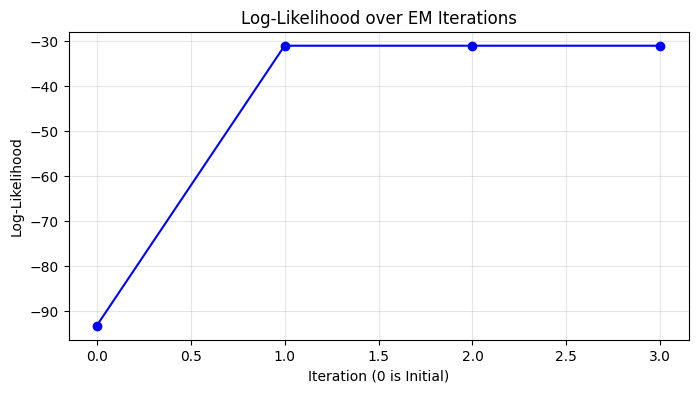

Log-Likelihoods: [np.float64(-93.2792182074559), np.float64(-31.126519501428586), np.float64(-31.126215596107293), np.float64(-31.126211819951166)]


In [90]:
epsilon = 1e-6

log_likelihoods = []

def mvn_pdf(x, mean, cov):
    n = len(mean)
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    diff = x - mean
    exponent = -0.5 * (diff @ inv @ diff.T)
    return (1.0 / np.sqrt(((2 * np.pi)**n) * det)) * np.exp(exponent)

# Calculate initial Log-Likelihood before any updates
initial_ll = sum(np.log(sum(phi[j] * mvn_pdf(x, mu[j], sigma[j]) for j in range(k))) for x in X)
log_likelihoods.append(initial_ll)

for iter in range(3):
    # --- E-STEP ---
    w = np.zeros((n_samples, k))
    for i in range(n_samples):
        for j in range(k):
            w[i, j] = phi[j] * mvn_pdf(X[i], mu[j], sigma[j])
        w[i, :] /= np.sum(w[i, :])

    # --- M-STEP ---
    n_j = np.sum(w, axis=0)
    for j in range(k):
        phi[j] = n_j[j] / n_samples
        mu[j] = (w[:, j] @ X) / n_j[j]
        diff = X - mu[j]
        sigma[j] = (w[:, j] * diff.T @ diff) / n_j[j] + np.eye(n_features) * epsilon
    
    # Calculate Log-Likelihood after update
    ll = sum(np.log(sum(phi[j] * mvn_pdf(x, mu[j], sigma[j]) for j in range(k))) for x in X)
    log_likelihoods.append(ll)

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(range(len(log_likelihoods)), log_likelihoods, marker='o', linestyle='-', color='b')
plt.title("Log-Likelihood over EM Iterations")
plt.xlabel("Iteration (0 is Initial)")
plt.ylabel("Log-Likelihood")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Log-Likelihoods: {log_likelihoods}")

#### 4. Plot the log likelihood of the model given the data after each EM step. Compare the log
likelihood between using two mixtures and three mixtures. Which one has the better likelihood?
(3 points)

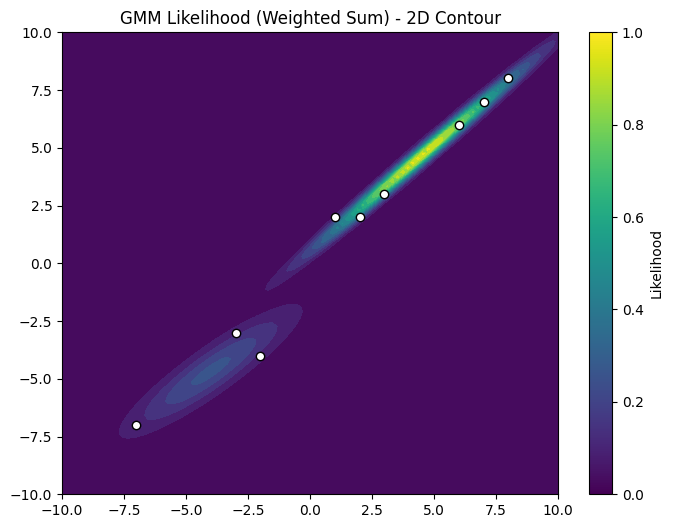

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Create a grid for the plot
x_range = np.linspace(-10, 10, 100)
y_range = np.linspace(-10, 10, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
pos = np.dstack((X_grid, Y_grid))

# Calculate weighted sum of Gaussians
Z = np.zeros(X_grid.shape)
for j in range(k):
    Z += phi[j] * multivariate_normal(mu[j], sigma[j]).pdf(pos)

plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', label='Data Points')
plt.title("GMM Likelihood (Weighted Sum) - 2D Contour")
plt.colorbar(label='Likelihood')
plt.show()

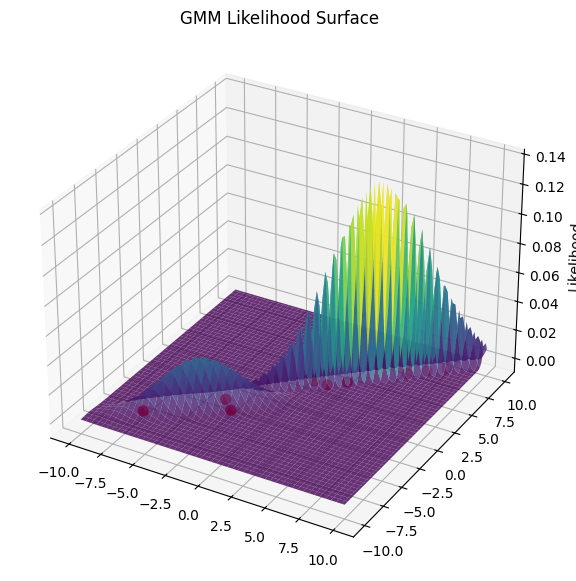

In [92]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_grid, Y_grid, Z, cmap='viridis', alpha=0.8)
ax.scatter(X[:, 0], X[:, 1], 0, c='red', s=50, label='Data (at Z=0)')
ax.set_zlabel('Likelihood')
plt.title("GMM Likelihood Surface")
plt.show()

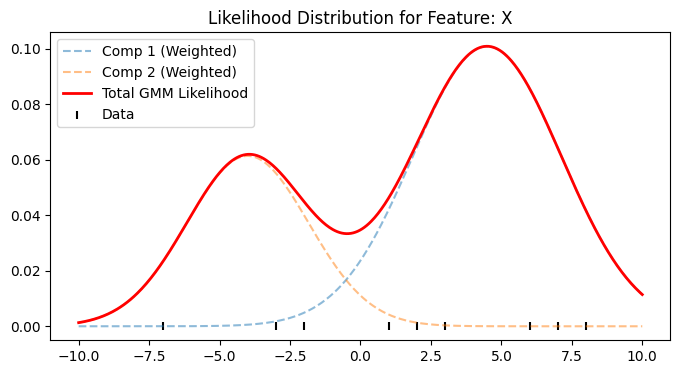

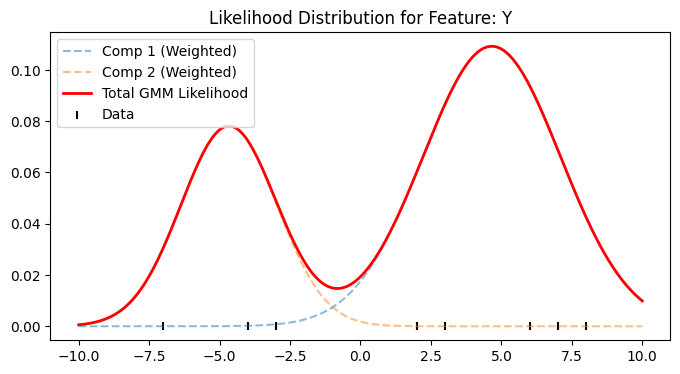

In [93]:
def plot_marginal(feature_index, label):
    x_line = np.linspace(-10, 10, 500)
    total_pdf = np.zeros_like(x_line)
    
    plt.figure(figsize=(8, 4))
    for j in range(k):
        # Use mean and variance of specific feature
        m = mu[j][feature_index]
        s = np.sqrt(sigma[j][feature_index, feature_index])
        
        # Calculate weighted component
        component_pdf = phi[j] * (1/(s * np.sqrt(2*np.pi)) * np.exp(-0.5*((x_line-m)/s)**2))
        total_pdf += component_pdf
        plt.plot(x_line, component_pdf, '--', alpha=0.5, label=f'Comp {j+1} (Weighted)')

    plt.plot(x_line, total_pdf, 'r-', linewidth=2, label='Total GMM Likelihood')
    plt.scatter(X[:, feature_index], np.zeros(len(X)), c='black', marker='|', label='Data')
    plt.title(f"Likelihood Distribution for Feature: {label}")
    plt.legend()
    plt.show()

plot_marginal(0, 'X')
plot_marginal(1, 'Y')

Hint 01: From HW3 – GMM Questions 1 and 3, you are required to plot the likelihood distribution
of the GMM at each iteration.
Normally, we plot a likelihood distribution using the Gaussian equation (in this case, a 2-
dimensional single Gaussian). However, when plotting the likelihood of a Gaussian Mixture Model
(GMM), students must first combine the Gaussian equations into the weighted sum of all Gaussian

components before plotting.
If students plot each Gaussian component separately, the resulting visualization will be incorrect,
because the components have not been weighted by the mixing coefficient mj
.

Students may choose one of the following plotting methods (do not forget to plot the data points on
the graph as well):

• 3D plot

o x, yaxes: features

o zaxis: likelihood

• 2D contour plot

o x, yaxes: features

o color intensity: likelihood

• 2D plots for each feature separately

o xaxis: feature

o yaxis: likelihood